In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

import os

In [2]:
from src.utils import _isotope_to_element, _isotope_label, _combine_elements
from src.plot import plot_yields
from src.load_data import load_ishigaki
from params import heger_woosley_2002_yields, filter_elements


In [3]:
def load_hw2002(filepath=heger_woosley_2002_yields):
    """Load Heger & Woosley 2002 yields.

    Fixed-width format:
      header:  isotope <mass_he_1> <mass_he_2> ... <mass_he_N>
      rows:    <isotope> <yield_at_mass_he_1> ...

    The column header values are He-core masses.  Total initial mass is
    computed via _mass_he_to_total and stored in params alongside mass_he.
    """
    with open(filepath) as f:
        lines = f.readlines()

    header_parts = lines[0].split()
    mass_he_values = [float(v) for v in header_parts[1:]]
    mass_he_to_total = lambda mass_he: mass_he * 2

    entries = []
    for ei, mass_he in enumerate(mass_he_values):
        mass = mass_he_to_total(mass_he)
        yld = {}
        for line in lines[1:]:
            parts = line.split()
            if len(parts) < ei + 2:
                continue
            label = _isotope_label(parts[0])
            val = float(parts[ei + 1])
            yld[label] = val

        entries.append({
            "label": f"M={mass:.0f}",
            "params": {"mass": mass, "mass_he": mass_he},
            "yields": yld,
        })

    return entries

hw_yields = load_hw2002(heger_woosley_2002_yields)

In [4]:
hw_yields = hw_yields[2:]

In [5]:
ishigaki18_yields = load_ishigaki()

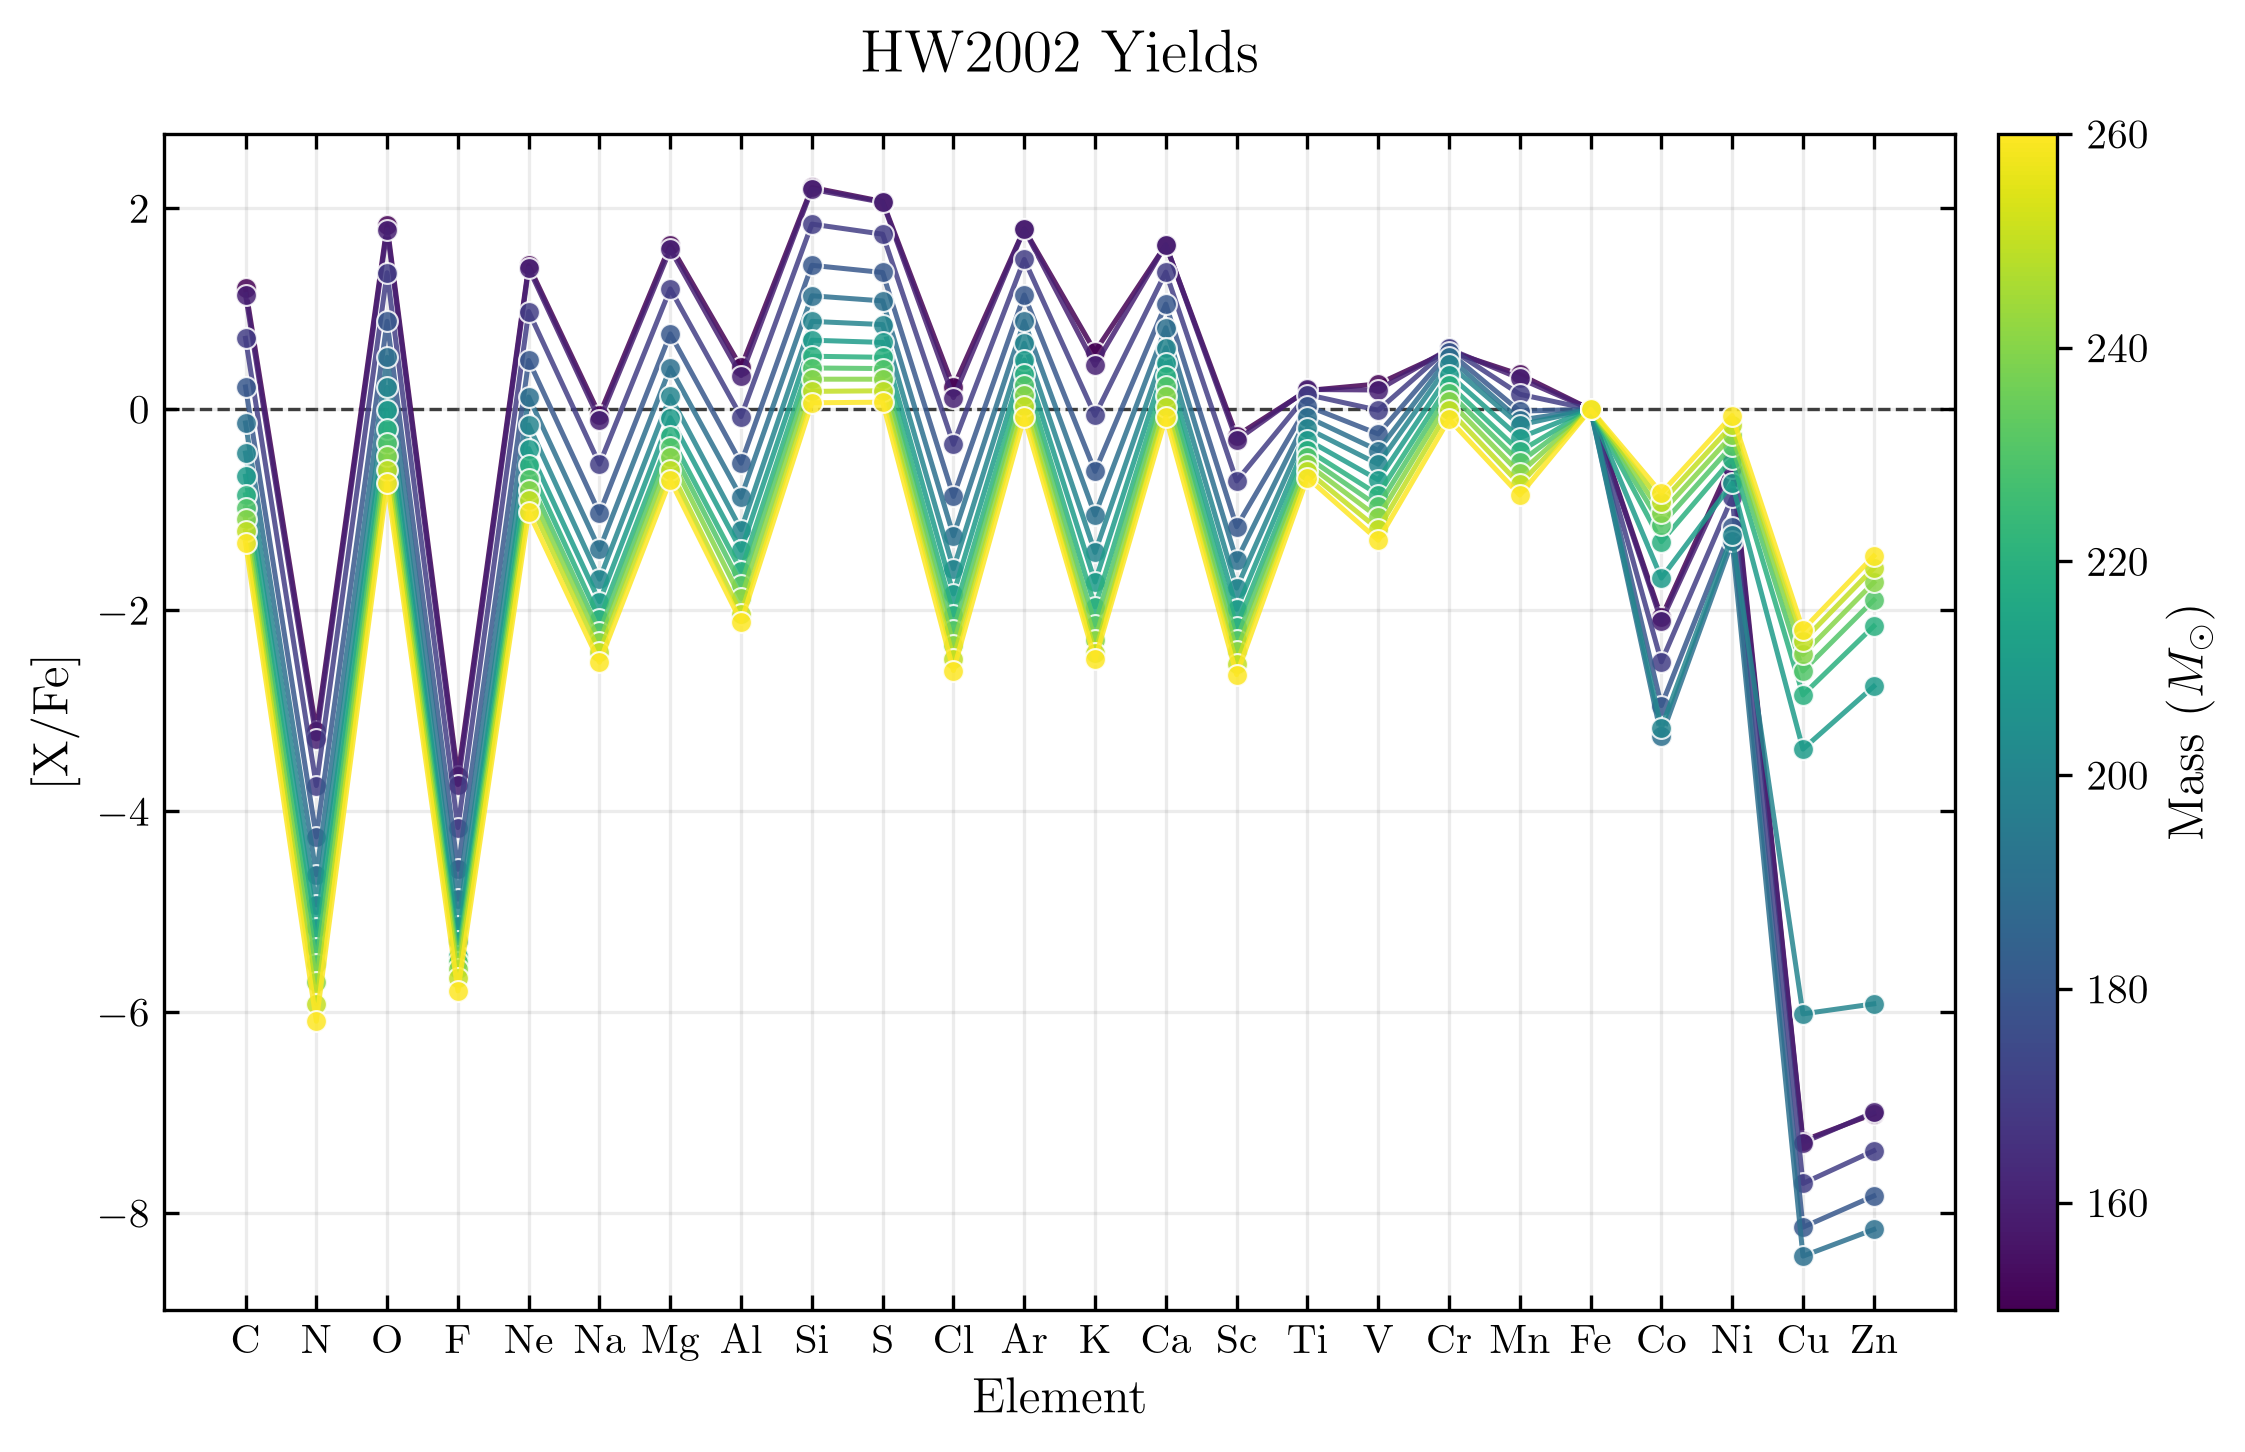

In [7]:
plot_yields(hw_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)